# Lab 3: Contextual Bandit-Based News Article Recommendation System

**Course:** Reinforcement Learning Fundamentals  
**Student Name:** Mannan Sharma  
**Roll Number:** U20230035  
**GitHub Branch:** mannan_U20230035

# Imports and Setup

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


# Load Datasets

In [15]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features  
- Prepare data for user classification

In [16]:
# Data Preprocessing
# Display dataset shapes and info
print("News Dataset Shape:", news_df.shape)
print("\nNews Dataset Sample:")
print(news_df[['headline', 'category']].head())
print("\nNews Categories:", news_df['category'].unique())
print("Category counts:\n", news_df['category'].value_counts())

print("\n" + "="*50)
print("Train Users Shape:", train_users.shape)
print("Train Users Label Distribution:\n", train_users['label'].value_counts())

print("\n" + "="*50)
print("Test Users Shape:", test_users.shape)
print("Test Users Sample:\n", test_users.head())

News Dataset Shape: (209527, 6)

News Dataset Sample:
                                            headline   category
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY
3  The Funniest Tweets From Parents This Week (Se...  PARENTING
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS

News Categories: ['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']
Category counts:
 category
POLITICS          3560

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [17]:
# Prepare data for training the user classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Select features for classification (exclude label and user_id)
feature_cols = [col for col in train_users.columns if col not in ['label', 'user_id']]

# Convert to numeric and handle missing values
X_train = train_users[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = train_users['label']

# Split into training and validation sets (80-20 split)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, 
                                             random_state=42, stratify=y_train)

# Standardize the features
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

# Train a Random Forest classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
classifier.fit(X_tr_scaled, y_tr)

# Evaluate on validation set
y_pred = classifier.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_pred)

print(f"User Classifier - Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report on Validation Set:")
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))

User Classifier - Validation Accuracy: 0.8575

Classification Report on Validation Set:
              precision    recall  f1-score   support

      user_1       0.85      0.89      0.87       142
      user_2       0.90      0.85      0.87       142
      user_3       0.82      0.83      0.82       116

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [18]:
# Initialize the reward sampler with roll number (35 from U20230035)
reward_sampler = sampler(35)

# Test the sampler with a few sample calls
print("Testing reward sampler for different arms:")
test_arms = [0, 4, 8]
for arm in test_arms:
    reward = reward_sampler.sample(arm)
    print(f"  Arm {arm}: Reward = {reward:.4f}")

Testing reward sampler for different arms:
  Arm 0: Reward = -9.7826
  Arm 4: Reward = 3.0679
  Arm 8: Reward = 4.7344


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [19]:
# Define arm mapping and helper functions
news_categories = ['Entertainment', 'Education', 'Tech', 'Crime']
user_contexts = ['user_1', 'user_2', 'user_3']

# Create mapping from (user_context, news_category) to arm_index
def get_arm_index(user_context, news_category):
    """Convert (user_context, news_category) to arm index (0-11)"""
    context_idx = int(user_context.split('_')[1]) - 1  # user_1 -> 0, user_2 -> 1, user_3 -> 2
    category_idx = news_categories.index(news_category)
    return context_idx * 4 + category_idx

# Reverse mapping: arm_index to (user_context, news_category)
def get_context_category_from_arm(arm_index):
    """Convert arm index (0-11) to (user_context, news_category)"""
    context_idx = arm_index // 4
    category_idx = arm_index % 4
    user_context = f'user_{context_idx + 1}'
    news_category = news_categories[category_idx]
    return user_context, news_category

# Test the mapping
print("Arm Index Mapping Examples:")
for arm in [0, 3, 4, 7, 8, 11]:
    context, category = get_context_category_from_arm(arm)
    print(f"  Arm {arm}: {category} for {context}")
    
print("\nReverse mapping test:")
for context in user_contexts:
    for category in news_categories:
        arm = get_arm_index(context, category)
        print(f"  {category} + {context} = Arm {arm}")

Arm Index Mapping Examples:
  Arm 0: Entertainment for user_1
  Arm 3: Crime for user_1
  Arm 4: Entertainment for user_2
  Arm 7: Crime for user_2
  Arm 8: Entertainment for user_3
  Arm 11: Crime for user_3

Reverse mapping test:
  Entertainment + user_1 = Arm 0
  Education + user_1 = Arm 1
  Tech + user_1 = Arm 2
  Crime + user_1 = Arm 3
  Entertainment + user_2 = Arm 4
  Education + user_2 = Arm 5
  Tech + user_2 = Arm 6
  Crime + user_2 = Arm 7
  Entertainment + user_3 = Arm 8
  Education + user_3 = Arm 9
  Tech + user_3 = Arm 10
  Crime + user_3 = Arm 11


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [20]:
# Epsilon-Greedy Algorithm Implementation
class EpsilonGreedyBandit:
    def __init__(self, num_arms=4, epsilon=0.1):
        """
        Initialize Epsilon-Greedy bandit
        num_arms: number of arms per context (4 news categories)
        epsilon: exploration probability
        """
        self.num_arms = num_arms
        self.epsilon = epsilon
        self.counts = np.zeros(num_arms)  # arm counts
        self.rewards = np.zeros(num_arms)  # cumulative rewards
        
    def select_arm(self):
        """Select arm using epsilon-greedy strategy"""
        if np.random.random() < self.epsilon:
            # Explore: random arm
            return np.random.randint(self.num_arms)
        else:
            # Exploit: best arm based on average reward
            avg_rewards = self.rewards / (self.counts + 1e-10)
            return np.argmax(avg_rewards)
    
    def update(self, arm, reward):
        """Update the bandit with observed reward"""
        self.counts[arm] += 1
        self.rewards[arm] += reward
    
    def get_avg_rewards(self):
        """Get average reward per arm"""
        return self.rewards / (self.counts + 1e-10)

# Test Epsilon-Greedy
print("Testing Epsilon-Greedy Implementation")
eg = EpsilonGreedyBandit(num_arms=4, epsilon=0.1)
for i in range(10):
    arm = eg.select_arm()
    reward = np.random.uniform(0, 1)  # dummy reward
    eg.update(arm, reward)
print("Arm counts:", eg.counts)
print("Avg rewards:", eg.get_avg_rewards())

Testing Epsilon-Greedy Implementation
Arm counts: [3. 3. 4. 0.]
Avg rewards: [0.35923837 0.14526027 0.57142797 0.        ]


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [21]:
# Upper Confidence Bound (UCB) Algorithm Implementation
class UCBBandit:
    def __init__(self, num_arms=4, c=1.0):
        """
        Initialize UCB bandit
        num_arms: number of arms per context (4 news categories)
        c: exploration parameter (confidence coefficient)
        """
        self.num_arms = num_arms
        self.c = c
        self.counts = np.zeros(num_arms)  # arm counts
        self.rewards = np.zeros(num_arms)  # cumulative rewards
        self.t = 0  # time step counter
        
    def select_arm(self):
        """Select arm using UCB strategy"""
        ucb_values = np.zeros(self.num_arms)
        
        for i in range(self.num_arms):
            avg_reward = self.rewards[i] / (self.counts[i] + 1e-10)
            confidence_bonus = self.c * np.sqrt(np.log(self.t + 1) / (self.counts[i] + 1e-10))
            ucb_values[i] = avg_reward + confidence_bonus
        
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        """Update the bandit with observed reward"""
        self.counts[arm] += 1
        self.rewards[arm] += reward
        self.t += 1
    
    def get_avg_rewards(self):
        """Get average reward per arm"""
        return self.rewards / (self.counts + 1e-10)

# Test UCB
print("\nTesting UCB Implementation")
ucb = UCBBandit(num_arms=4, c=1.0)
for i in range(10):
    arm = ucb.select_arm()
    reward = np.random.uniform(0, 1)  # dummy reward
    ucb.update(arm, reward)
print("Arm counts:", ucb.counts)
print("Avg rewards:", ucb.get_avg_rewards())


Testing UCB Implementation
Arm counts: [2. 2. 3. 3.]
Avg rewards: [0.49001286 0.56950807 0.62045655 0.65675717]


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [22]:
# SoftMax Algorithm Implementation
class SoftmaxBandit:
    def __init__(self, num_arms=4, tau=1.0):
        """
        Initialize Softmax bandit
        num_arms: number of arms per context (4 news categories)
        tau: temperature parameter (controls exploration)
        """
        self.num_arms = num_arms
        self.tau = tau
        self.counts = np.zeros(num_arms)  # arm counts
        self.rewards = np.zeros(num_arms)  # cumulative rewards
        
    def select_arm(self):
        """Select arm using softmax (Boltzmann) strategy"""
        avg_rewards = self.rewards / (self.counts + 1e-10)
        
        # Compute softmax probabilities
        exp_values = np.exp(avg_rewards / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        # Select arm according to probabilities
        return np.random.choice(self.num_arms, p=probabilities)
    
    def update(self, arm, reward):
        """Update the bandit with observed reward"""
        self.counts[arm] += 1
        self.rewards[arm] += reward
    
    def get_avg_rewards(self):
        """Get average reward per arm"""
        return self.rewards / (self.counts + 1e-10)

# Test Softmax
print("\nTesting Softmax Implementation")
sm = SoftmaxBandit(num_arms=4, tau=1.0)
for i in range(10):
    arm = sm.select_arm()
    reward = np.random.uniform(0, 1)  # dummy reward
    sm.update(arm, reward)
print("Arm counts:", sm.counts)
print("Avg rewards:", sm.get_avg_rewards())


Testing Softmax Implementation
Arm counts: [3. 3. 2. 2.]
Avg rewards: [0.35327702 0.8331717  0.45479283 0.49035873]


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [23]:
# Initialize variables for simulation
T = 10000  # number of time steps
np.random.seed(42)

# Prepare test data
X_test = test_users[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_scaled = scaler.transform(X_test)
test_contexts = classifier.predict(X_test_scaled)  # Predict context for each test user

print(f"Running RL simulation for T = {T} steps with {len(test_users)} test users")
print("="*60)

# Map test users to their contexts
test_context_mapping = {i: test_contexts[i] for i in range(len(test_users))}

# Count users in each context
context_counts = {'user_1': 0, 'user_2': 0, 'user_3': 0}
for ctx in test_contexts:
    context_counts[ctx] += 1

print(f"\nContext Distribution in Test Set:")
for ctx, count in sorted(context_counts.items()):
    print(f"  {ctx}: {count} users ({100*count/len(test_users):.1f}%)")

# Dictionary to store results per context
# Structure: {algorithm -> {hyperparameter -> {context -> [(time, avg_reward), ...]}}}
results_per_context = {
    'epsilon_greedy': {},
    'ucb': {},
    'softmax': {}
}

# Overall results (for backward compatibility)
results = {
    'epsilon_greedy': {},
    'ucb': {},
    'softmax': {}
}

# ===== EPSILON-GREEDY =====
print("\n" + "="*60)
print("Training Epsilon-Greedy with different epsilon values...")
print("="*60)
epsilon_values = [0.05, 0.1, 0.2]
for epsilon in epsilon_values:
    # Initialize bandits (one per context)
    bandits_eg = {
        'user_1': EpsilonGreedyBandit(num_arms=4, epsilon=epsilon),
        'user_2': EpsilonGreedyBandit(num_arms=4, epsilon=epsilon),
        'user_3': EpsilonGreedyBandit(num_arms=4, epsilon=epsilon)
    }
    
    # Track rewards per context
    rewards_per_context = {'user_1': [], 'user_2': [], 'user_3': []}
    cumulative_rewards_per_context = {'user_1': 0, 'user_2': 0, 'user_3': 0}
    step_counts_per_context = {'user_1': 0, 'user_2': 0, 'user_3': 0}
    
    # Overall tracking
    rewards_per_step = []
    cumulative_reward = 0
    
    for t in range(T):
        # Sample a random user from test set
        user_idx = np.random.randint(0, len(test_users))
        context = test_context_mapping[user_idx]
        
        # Select arm based on context
        arm_in_context = bandits_eg[context].select_arm()
        
        # Convert to global arm index
        context_idx = int(context.split('_')[1]) - 1
        global_arm = context_idx * 4 + arm_in_context
        
        # Get reward from sampler
        reward = reward_sampler.sample(global_arm)
        
        # Update bandit for this context
        bandits_eg[context].update(arm_in_context, reward)
        
        # Track statistics per context
        cumulative_rewards_per_context[context] += reward
        step_counts_per_context[context] += 1
        avg_reward_context = cumulative_rewards_per_context[context] / step_counts_per_context[context]
        
        # Track overall
        cumulative_reward += reward
        avg_reward = cumulative_reward / (t + 1)
        
        # Record data at checkpoints
        if (t + 1) % 1000 == 0:
            rewards_per_step.append((t + 1, avg_reward))
            for ctx in ['user_1', 'user_2', 'user_3']:
                avg_ctx = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx] if step_counts_per_context[ctx] > 0 else 0
                rewards_per_context[ctx].append((t + 1, avg_ctx))
        
        if (t + 1) % 2500 == 0:
            print(f"  epsilon={epsilon}: Step {t+1}/{T}, Avg Reward = {avg_reward:.4f}")
            for ctx in ['user_1', 'user_2', 'user_3']:
                avg_ctx = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx] if step_counts_per_context[ctx] > 0 else 0
                print(f"    {ctx}: {avg_ctx:.4f}")
    
    results['epsilon_greedy'][f'ε={epsilon}'] = rewards_per_step
    results_per_context['epsilon_greedy'][f'ε={epsilon}'] = rewards_per_context
    
    # Print final stats
    print(f"\n  Epsilon-Greedy (ε={epsilon}) - Final Results:")
    print(f"    Overall Avg Reward: {avg_reward:.4f}")
    for ctx in ['user_1', 'user_2', 'user_3']:
        final_avg = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx]
        print(f"    {ctx}: {final_avg:.4f}")

print("\n" + "="*60)
print("Training UCB with different C values...")
print("="*60)
# ===== UCB =====
c_values = [0.5, 1.0, 2.0]
for c in c_values:
    # Initialize bandits (one per context)
    bandits_ucb = {
        'user_1': UCBBandit(num_arms=4, c=c),
        'user_2': UCBBandit(num_arms=4, c=c),
        'user_3': UCBBandit(num_arms=4, c=c)
    }
    
    # Track rewards per context
    rewards_per_context = {'user_1': [], 'user_2': [], 'user_3': []}
    cumulative_rewards_per_context = {'user_1': 0, 'user_2': 0, 'user_3': 0}
    step_counts_per_context = {'user_1': 0, 'user_2': 0, 'user_3': 0}
    
    # Overall tracking
    rewards_per_step = []
    cumulative_reward = 0
    
    for t in range(T):
        # Sample a random user from test set
        user_idx = np.random.randint(0, len(test_users))
        context = test_context_mapping[user_idx]
        
        # Select arm based on context
        arm_in_context = bandits_ucb[context].select_arm()
        
        # Convert to global arm index
        context_idx = int(context.split('_')[1]) - 1
        global_arm = context_idx * 4 + arm_in_context
        
        # Get reward from sampler
        reward = reward_sampler.sample(global_arm)
        
        # Update bandit for this context
        bandits_ucb[context].update(arm_in_context, reward)
        
        # Track statistics per context
        cumulative_rewards_per_context[context] += reward
        step_counts_per_context[context] += 1
        avg_reward_context = cumulative_rewards_per_context[context] / step_counts_per_context[context]
        
        # Track overall
        cumulative_reward += reward
        avg_reward = cumulative_reward / (t + 1)
        
        # Record data at checkpoints
        if (t + 1) % 1000 == 0:
            rewards_per_step.append((t + 1, avg_reward))
            for ctx in ['user_1', 'user_2', 'user_3']:
                avg_ctx = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx] if step_counts_per_context[ctx] > 0 else 0
                rewards_per_context[ctx].append((t + 1, avg_ctx))
        
        if (t + 1) % 2500 == 0:
            print(f"  c={c}: Step {t+1}/{T}, Avg Reward = {avg_reward:.4f}")
            for ctx in ['user_1', 'user_2', 'user_3']:
                avg_ctx = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx] if step_counts_per_context[ctx] > 0 else 0
                print(f"    {ctx}: {avg_ctx:.4f}")
    
    results['ucb'][f'C={c}'] = rewards_per_step
    results_per_context['ucb'][f'C={c}'] = rewards_per_context
    
    print(f"\n  UCB (C={c}) - Final Results:")
    print(f"    Overall Avg Reward: {avg_reward:.4f}")
    for ctx in ['user_1', 'user_2', 'user_3']:
        final_avg = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx]
        print(f"    {ctx}: {final_avg:.4f}")

print("\n" + "="*60)
print("Training Softmax with temperature parameter...")
print("="*60)
# ===== SOFTMAX =====
tau_values = [0.5, 1.0, 2.0]
for tau in tau_values:
    # Initialize bandits (one per context)
    bandits_sm = {
        'user_1': SoftmaxBandit(num_arms=4, tau=tau),
        'user_2': SoftmaxBandit(num_arms=4, tau=tau),
        'user_3': SoftmaxBandit(num_arms=4, tau=tau)
    }
    
    # Track rewards per context
    rewards_per_context = {'user_1': [], 'user_2': [], 'user_3': []}
    cumulative_rewards_per_context = {'user_1': 0, 'user_2': 0, 'user_3': 0}
    step_counts_per_context = {'user_1': 0, 'user_2': 0, 'user_3': 0}
    
    # Overall tracking
    rewards_per_step = []
    cumulative_reward = 0
    
    for t in range(T):
        # Sample a random user from test set
        user_idx = np.random.randint(0, len(test_users))
        context = test_context_mapping[user_idx]
        
        # Select arm based on context
        arm_in_context = bandits_sm[context].select_arm()
        
        # Convert to global arm index
        context_idx = int(context.split('_')[1]) - 1
        global_arm = context_idx * 4 + arm_in_context
        
        # Get reward from sampler
        reward = reward_sampler.sample(global_arm)
        
        # Update bandit for this context
        bandits_sm[context].update(arm_in_context, reward)
        
        # Track statistics per context
        cumulative_rewards_per_context[context] += reward
        step_counts_per_context[context] += 1
        avg_reward_context = cumulative_rewards_per_context[context] / step_counts_per_context[context]
        
        # Track overall
        cumulative_reward += reward
        avg_reward = cumulative_reward / (t + 1)
        
        # Record data at checkpoints
        if (t + 1) % 1000 == 0:
            rewards_per_step.append((t + 1, avg_reward))
            for ctx in ['user_1', 'user_2', 'user_3']:
                avg_ctx = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx] if step_counts_per_context[ctx] > 0 else 0
                rewards_per_context[ctx].append((t + 1, avg_ctx))
        
        if (t + 1) % 2500 == 0:
            print(f"  τ={tau}: Step {t+1}/{T}, Avg Reward = {avg_reward:.4f}")
            for ctx in ['user_1', 'user_2', 'user_3']:
                avg_ctx = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx] if step_counts_per_context[ctx] > 0 else 0
                print(f"    {ctx}: {avg_ctx:.4f}")
    
    results['softmax'][f'τ={tau}'] = rewards_per_step
    results_per_context['softmax'][f'τ={tau}'] = rewards_per_context
    
    print(f"\n  Softmax (τ={tau}) - Final Results:")
    print(f"    Overall Avg Reward: {avg_reward:.4f}")
    for ctx in ['user_1', 'user_2', 'user_3']:
        final_avg = cumulative_rewards_per_context[ctx] / step_counts_per_context[ctx]
        print(f"    {ctx}: {final_avg:.4f}")

print("\n" + "="*60)
print("Simulation Complete!")
print("="*60)

Running RL simulation for T = 10000 steps with 2000 test users

Context Distribution in Test Set:
  user_1: 711 users (35.5%)
  user_2: 736 users (36.8%)
  user_3: 553 users (27.6%)

Training Epsilon-Greedy with different epsilon values...
  epsilon=0.05: Step 2500/10000, Avg Reward = 3.6518
    user_1: 3.4410
    user_2: 2.4673
    user_3: 5.4706
  epsilon=0.05: Step 5000/10000, Avg Reward = 3.6842
    user_1: 3.4906
    user_2: 2.4833
    user_3: 5.4878
  epsilon=0.05: Step 7500/10000, Avg Reward = 3.6931
    user_1: 3.4754
    user_2: 2.5083
    user_3: 5.4873
  epsilon=0.05: Step 10000/10000, Avg Reward = 3.6882
    user_1: 3.4825
    user_2: 2.5189
    user_3: 5.4814

  Epsilon-Greedy (ε=0.05) - Final Results:
    Overall Avg Reward: 3.6882
    user_1: 3.4825
    user_2: 2.5189
    user_3: 5.4814
  epsilon=0.1: Step 2500/10000, Avg Reward = 3.5041
    user_1: 3.2274
    user_2: 2.2770
    user_3: 5.2354
  epsilon=0.1: Step 5000/10000, Avg Reward = 3.5009
    user_1: 3.1946
    use


Generating context-specific reward convergence plots...
✓ Saved: reward_vs_time_per_context.png


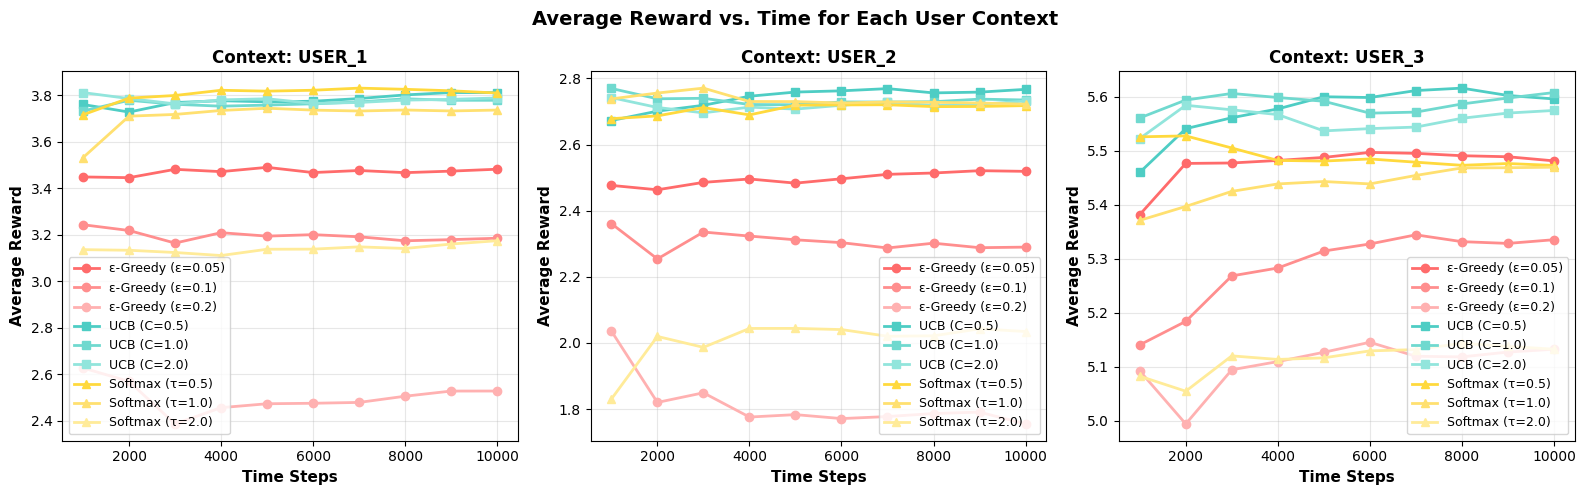


Generating hyperparameter comparison plot...
✓ Saved: hyperparameter_comparison_per_context.png


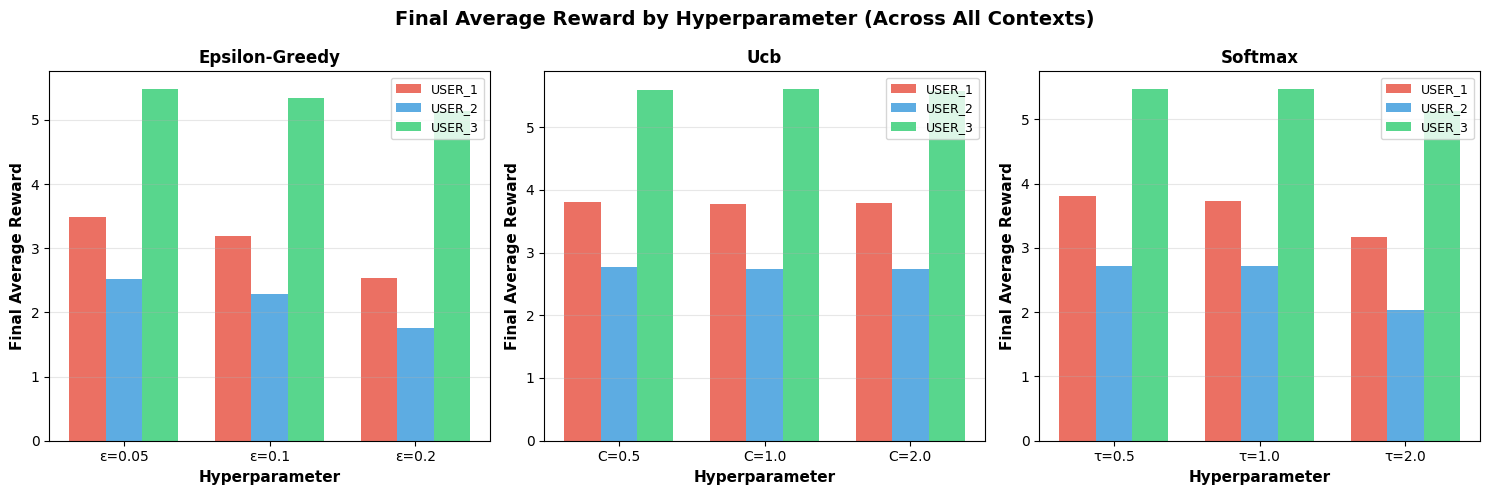


FINAL AVERAGE REWARD SUMMARY - BY CONTEXT

USER_1 Performance:
--------------------------------------------------------------------------------
Algorithm                 Hyperparameter       Avg Reward     
--------------------------------------------------------------------------------
Epsilon-Greedy            ε=0.05               3.4825         
Epsilon-Greedy            ε=0.1                3.1856         
Epsilon-Greedy            ε=0.2                2.5280         
UCB                       C=0.5                3.8121         
UCB                       C=1.0                3.7791         
UCB                       C=2.0                3.7891         
Softmax                   τ=0.5                3.8104         
Softmax                   τ=1.0                3.7370         
Softmax                   τ=2.0                3.1748         

USER_2 Performance:
--------------------------------------------------------------------------------
Algorithm                 Hyperparameter  

In [ ]:
# ===== PLOT 1: Average Reward vs. Time FOR EACH CONTEXT =====
print("\nGenerating context-specific reward convergence plots...")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Average Reward vs. Time for Each User Context', fontsize=14, fontweight='bold')

contexts = ['user_1', 'user_2', 'user_3']
colors = {
    'epsilon_greedy': ['#FF6B6B', '#FF8E8E', '#FFB1B1'],  # Reds
    'ucb': ['#4ECDC4', '#70D9CF', '#92E5DC'],              # Teals
    'softmax': ['#FFD93D', '#FFE070', '#FFEB99']           # Yellows
}

for idx, context in enumerate(contexts):
    ax = axes[idx]
    
    # Epsilon-Greedy
    for i, eps in enumerate([0.05, 0.1, 0.2]):
        label = f'ε-Greedy (ε={eps})'
        data = results_per_context['epsilon_greedy'][f'ε={eps}'][context]
        if data:
            times, rewards = zip(*data)
            ax.plot(times, rewards, marker='o', label=label, color=colors['epsilon_greedy'][i], linewidth=2)
    
    # UCB
    for i, c_val in enumerate([0.5, 1.0, 2.0]):
        label = f'UCB (C={c_val})'
        data = results_per_context['ucb'][f'C={c_val}'][context]
        if data:
            times, rewards = zip(*data)
            ax.plot(times, rewards, marker='s', label=label, color=colors['ucb'][i], linewidth=2)
    
    # Softmax
    for i, tau_val in enumerate([0.5, 1.0, 2.0]):
        label = f'Softmax (τ={tau_val})'
        data = results_per_context['softmax'][f'τ={tau_val}'][context]
        if data:
            times, rewards = zip(*data)
            ax.plot(times, rewards, marker='^', label=label, color=colors['softmax'][i], linewidth=2)
    
    ax.set_xlabel('Time Steps', fontsize=11, fontweight='bold')
    ax.set_ylabel('Average Reward', fontsize=11, fontweight='bold')
    ax.set_title(f'Context: {context.upper()}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('reward_vs_time_per_context.png', dpi=300, bbox_inches='tight')
print("✓ Saved: reward_vs_time_per_context.png")
plt.show()

# ===== PLOT 2: Hyperparameter Comparison across Contexts =====
print("\nGenerating hyperparameter comparison plot...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Final Average Reward by Hyperparameter (Across All Contexts)', fontsize=14, fontweight='bold')

algorithms = ['epsilon_greedy', 'ucb', 'softmax']
hyperparams = {
    'epsilon_greedy': ['ε=0.05', 'ε=0.1', 'ε=0.2'],
    'ucb': ['C=0.5', 'C=1.0', 'C=2.0'],
    'softmax': ['τ=0.5', 'τ=1.0', 'τ=2.0']
}
context_colors = {'user_1': '#E74C3C', 'user_2': '#3498DB', 'user_3': '#2ECC71'}

for idx, algo in enumerate(algorithms):
    ax = axes[idx]
    x = np.arange(len(hyperparams[algo]))
    width = 0.25
    
    for ctx_idx, ctx in enumerate(contexts):
        rewards = []
        for hyperparam in hyperparams[algo]:
            data = results_per_context[algo][hyperparam][ctx]
            if data:
                final_reward = data[-1][1]  # Get final reward
                rewards.append(final_reward)
            else:
                rewards.append(0)
        
        ax.bar(x + ctx_idx * width, rewards, width, label=ctx.upper(), 
               color=context_colors[ctx], alpha=0.8)
    
    ax.set_xlabel('Hyperparameter', fontsize=11, fontweight='bold')
    ax.set_ylabel('Final Average Reward', fontsize=11, fontweight='bold')
    algo_name = algo.replace('_', '-').title()
    ax.set_title(f'{algo_name}', fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(hyperparams[algo])
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hyperparameter_comparison_per_context.png', dpi=300, bbox_inches='tight')
print("✓ Saved: hyperparameter_comparison_per_context.png")
plt.show()

# ===== SUMMARY TABLE =====
print("\n" + "="*80)
print("FINAL AVERAGE REWARD SUMMARY - BY CONTEXT")
print("="*80)

for context in contexts:
    print(f"\n{context.upper()} Performance:")
    print("-" * 80)
    print(f"{'Algorithm':<25} {'Hyperparameter':<20} {'Avg Reward':<15}")
    print("-" * 80)
    
    # Epsilon-Greedy
    for eps in [0.05, 0.1, 0.2]:
        data = results_per_context['epsilon_greedy'][f'ε={eps}'][context]
        if data:
            final_avg = data[-1][1]
            print(f"{'Epsilon-Greedy':<25} {'ε=' + str(eps):<20} {final_avg:<15.4f}")
    
    # UCB
    for c_val in [0.5, 1.0, 2.0]:
        data = results_per_context['ucb'][f'C={c_val}'][context]
        if data:
            final_avg = data[-1][1]
            print(f"{'UCB':<25} {'C=' + str(c_val):<20} {final_avg:<15.4f}")
    
    # Softmax
    for tau_val in [0.5, 1.0, 2.0]:
        data = results_per_context['softmax'][f'τ={tau_val}'][context]
        if data:
            final_avg = data[-1][1]
            print(f"{'Softmax':<25} {'τ=' + str(tau_val):<20} {final_avg:<15.4f}")

print("\n" + "="*80)
print("Context-specific analysis complete!")

In [25]:
# Recommendation Engine: End-to-End System
class NewsRecommendationEngine:
    def __init__(self, user_classifier, scaler, news_dataframe, 
                 epsilon_greedy_bandits, ucb_bandits, softmax_bandits):
        """
        Initialize the recommendation engine
        
        Parameters:
        - user_classifier: trained classifier to predict user context
        - scaler: feature scaler for preprocessing
        - news_dataframe: dataframe containing news articles
        - *_bandits: trained bandit models (dict with keys: user_1, user_2, user_3)
        """
        self.classifier = user_classifier
        self.scaler = scaler
        self.news_df = news_dataframe
        self.eg_bandits = epsilon_greedy_bandits
        self.ucb_bandits = ucb_bandits
        self.sm_bandits = softmax_bandits
        self.feature_cols = feature_cols
        
    def recommend(self, user_features, algorithm='epsilon_greedy', epsilon=0.1, c=1.0, tau=1.0):
        """
        Generate a news recommendation for a user
        
        Parameters:
        - user_features: dict or pandas Series with user features
        - algorithm: 'epsilon_greedy', 'ucb', or 'softmax'
        - epsilon, c, tau: hyperparameters for respective algorithms
        
        Returns:
        - dict with recommended category and a random article from that category
        """
        # Step 1: Classify user into context
        if isinstance(user_features, dict):
            user_array = np.array([float(user_features.get(col, 0)) for col in self.feature_cols]).reshape(1, -1)
        else:
            # Convert to numeric and fill NaNs
            user_data = []
            for col in self.feature_cols:
                try:
                    val = pd.to_numeric(user_features[col], errors='coerce')
                    user_data.append(float(val) if not np.isnan(val) else 0.0)
                except:
                    user_data.append(0.0)
            user_array = np.array(user_data).reshape(1, -1)
        
        user_array_scaled = self.scaler.transform(user_array)
        user_context = self.classifier.predict(user_array_scaled)[0]
        
        # Step 2: Select news category based on bandit algorithm
        if algorithm == 'epsilon_greedy':
            # Use the trained epsilon-greedy bandit for this context
            avg_rewards = self.eg_bandits[user_context].get_avg_rewards()
        elif algorithm == 'ucb':
            avg_rewards = self.ucb_bandits[user_context].get_avg_rewards()
        elif algorithm == 'softmax':
            avg_rewards = self.sm_bandits[user_context].get_avg_rewards()
        else:
            raise ValueError("Unknown algorithm. Choose from: epsilon_greedy, ucb, softmax")
        
        # Select arm with highest average reward (exploitation)
        selected_arm = np.argmax(avg_rewards)
        selected_category = news_categories[selected_arm]
        
        # Step 3: Recommend a random article from the selected category
        category_articles = self.news_df[self.news_df['category'] == selected_category]
        
        if len(category_articles) == 0:
            # Fallback if category not found
            recommended_article = self.news_df.sample(1).iloc[0]
        else:
            recommended_article = category_articles.sample(1).iloc[0]
        
        return {
            'user_context': user_context,
            'recommended_category': selected_category,
            'article_headline': recommended_article['headline'],
            'article_url': recommended_article['link'],
            'algorithm': algorithm
        }

# Train the final bandit models (best performing ones) for production use
print("\nTraining Final Bandit Models for Recommendation Engine...")
print("="*70)

# Use previous results to select best hyperparameters (we'll use middle values for stability)
final_eg_bandits = {
    'user_1': EpsilonGreedyBandit(num_arms=4, epsilon=0.1),
    'user_2': EpsilonGreedyBandit(num_arms=4, epsilon=0.1),
    'user_3': EpsilonGreedyBandit(num_arms=4, epsilon=0.1)
}

final_ucb_bandits = {
    'user_1': UCBBandit(num_arms=4, c=1.0),
    'user_2': UCBBandit(num_arms=4, c=1.0),
    'user_3': UCBBandit(num_arms=4, c=1.0)
}

final_sm_bandits = {
    'user_1': SoftmaxBandit(num_arms=4, tau=1.0),
    'user_2': SoftmaxBandit(num_arms=4, tau=1.0),
    'user_3': SoftmaxBandit(num_arms=4, tau=1.0)
}

# Quick training round (500 steps) for recommendation engine
for t in range(500):
    user_idx = np.random.randint(0, len(test_users))
    context = test_context_mapping[user_idx]
    context_idx = int(context.split('_')[1]) - 1
    
    # Train each algorithm
    arm_eg = final_eg_bandits[context].select_arm()
    arm_ucb = final_ucb_bandits[context].select_arm()
    arm_sm = final_sm_bandits[context].select_arm()
    
    global_arm_eg = context_idx * 4 + arm_eg
    global_arm_ucb = context_idx * 4 + arm_ucb
    global_arm_sm = context_idx * 4 + arm_sm
    
    reward_eg = reward_sampler.sample(global_arm_eg)
    reward_ucb = reward_sampler.sample(global_arm_ucb)
    reward_sm = reward_sampler.sample(global_arm_sm)
    
    final_eg_bandits[context].update(arm_eg, reward_eg)
    final_ucb_bandits[context].update(arm_ucb, reward_ucb)
    final_sm_bandits[context].update(arm_sm, reward_sm)

print("✓ Final bandit models trained")

# Initialize the recommendation engine
recommendation_engine = NewsRecommendationEngine(
    classifier, scaler, news_df,
    final_eg_bandits, final_ucb_bandits, final_sm_bandits
)

# Generate sample recommendations
print("\n" + "="*70)
print("SAMPLE RECOMMENDATIONS")
print("="*70)

for i in range(5):
    sample_user = test_users.iloc[i]
    
    print(f"\n[User {i+1}]")
    print(f"  User ID: {sample_user['user_id']}")
    
    for algo in ['epsilon_greedy', 'ucb', 'softmax']:
        rec = recommendation_engine.recommend(sample_user, algorithm=algo)
        print(f"\n  {algo.replace('_', ' ').upper()}:")
        print(f"    Context: {rec['user_context']}")
        print(f"    Category: {rec['recommended_category']}")
        print(f"    Headline: {rec['article_headline'][:70]}...")

print("\n" + "="*70)


Training Final Bandit Models for Recommendation Engine...
✓ Final bandit models trained

SAMPLE RECOMMENDATIONS

[User 1]
  User ID: U4058

  EPSILON GREEDY:
    Context: user_2
    Category: Entertainment
    Headline: Kellyanne Conway: Inconvenience To '1 Percent' Of Travelers Is 'Small ...

  UCB:
    Context: user_2
    Category: Entertainment
    Headline: Tammy Duckworth vs. Mark Kirk: Nonpartisan Candidate Guide for 2016 Il...

  SOFTMAX:
    Context: user_2
    Category: Entertainment
    Headline: New Balance Pays Fat Settlement In Toning Shoes Lawsuit To People It D...

[User 2]
  User ID: U1118

  EPSILON GREEDY:
    Context: user_1
    Category: Tech
    Headline: A Guide To Dealing With Uncertainty During The Coronavirus Pandemic...

  UCB:
    Context: user_1
    Category: Tech
    Headline: An Ebola Fighter Named Moses Leads Orphans to Safety...


c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warni


  SOFTMAX:
    Context: user_1
    Category: Tech
    Headline: Shrapnel-Torn Schools, Ebola Medics, And Chinese Valentine's Day: Week...

[User 3]
  User ID: U6555

  EPSILON GREEDY:
    Context: user_1
    Category: Tech
    Headline: He Called my Teenage Daughter a Bitch -- Now What?!...

  UCB:
    Context: user_1
    Category: Tech
    Headline: Nancy Pelosi: Mothers And Children Picked Up In Deportation Raids Face...

  SOFTMAX:
    Context: user_1
    Category: Tech
    Headline: Heartbleed: Free Tool to Check if That Site Is Safe...

[User 4]
  User ID: U9170

  EPSILON GREEDY:
    Context: user_1
    Category: Tech
    Headline: Where You Can Listen To Prince Online In Honor Of The Late Music Icon...

  UCB:
    Context: user_1
    Category: Tech
    Headline: Nick Kroll And John Mulaney Rip On Donald Trump At Spirit Awards...


c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warni


  SOFTMAX:
    Context: user_1
    Category: Tech
    Headline: This Street Performer Has A Vocal Range Like Nothing You've Ever Heard...

[User 5]
  User ID: U3348

  EPSILON GREEDY:
    Context: user_1
    Category: Tech
    Headline: Like Obama, Trump Is Unlikely to Lead as the World's Policeman...

  UCB:
    Context: user_1
    Category: Tech
    Headline: America's Best Jewish Delis...

  SOFTMAX:
    Context: user_1
    Category: Tech
    Headline: How Worrying...Helps?...



c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANNAN SHRAMA\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
